In [1]:
#1 IMPORTS


import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import entropy, iqr, kurtosis, skew
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt



In [2]:
# =========================
# 1. SETTINGS
# =========================

CSV_PATH = Path("Dataset1.csv")   # if notebook is in same folder as the CSV
FS = 200
WINDOW_SIZE = 180
HALF_WINDOW = WINDOW_SIZE // 2

FEATURE_COLS = [
    "AccX (g)", "AccY (g)", "AccZ (g)",
    "GyroX (deg/s)", "GyroY (deg/s)", "GyroZ (deg/s)"
]


In [3]:
# =========================
# 2. LOAD DATA
# =========================

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
df.head()


Shape: (101344, 27)
Columns:
['SensorId', 'TimeStamp (s)', 'FrameNumber', 'AccX (g)', 'AccY (g)', 'AccZ (g)', 'GyroX (deg/s)', 'GyroY (deg/s)', 'GyroZ (deg/s)', 'MagX (uT)', 'MagY (uT)', 'MagZ (uT)', 'EulerX (deg)', 'EulerY (deg)', 'EulerZ (deg)', 'QuatW', 'QuatX', 'QuatY', 'QuatZ', 'LinAccX (g)', 'LinAccY (g)', 'LinAccZ (g)', 'Pressure (kPa)', 'Altitude (m)', 'Temperature (degC)', 'HeaveMotion (m)', 'Type']


,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m),Type
0,1,0.000,0,-0.229679,0.957187,-0.201639,9.600825,-8.292289,0.082568,16.834721,...,-0.459202,0.820582,0.169380,-0.117906,-0.338705,0,0,0,0,NaN
1,1,0.005,1,-0.232886,0.957197,-0.201649,9.812190,-8.666814,0.008853,16.659359,...,-0.458990,0.820879,0.172690,-0.118253,-0.339230,0,0,0,0,NaN
2,1,0.010,2,-0.231898,0.956696,-0.200421,10.130239,-9.042031,-0.030537,16.659359,...,-0.458772,0.821185,0.171806,-0.118098,-0.341005,0,0,0,0,NaN
3,1,0.015,3,-0.236833,0.957947,-0.202149,10.127597,-9.552365,-0.034750,16.659359,...,-0.458562,0.821494,0.176830,-0.119696,-0.339824,0,0,0,0,NaN
4,1,0.020,4,-0.234854,0.956694,-0.198713,10.233678,-9.690810,0.207369,16.834721,...,-0.458350,0.821808,0.174952,-0.118786,-0.343802,0,0,0,0,NaN


In [4]:

# Check punch labels
print(df["Type"].value_counts(dropna=False))


Type
NaN         100956
Uppercut       163
Jab            122
Hook           103
Name: count, dtype: int64


In [5]:

# =========================
# 3. FEATURE EXTRACTION
# =========================

def signal_entropy(x, bins=20):
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    return float(entropy(hist)) if len(hist) else 0.0

def extract_axis_features(x, fs=FS, prefix="sig"):
    x = np.asarray(x)

    feats = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_iqr": float(iqr(x)),
        f"{prefix}_entropy": signal_entropy(x),
        f"{prefix}_skew": float(skew(x, bias=False)),
        f"{prefix}_kurtosis": float(kurtosis(x, fisher=True, bias=False)),
        f"{prefix}_mad": float(np.mean(np.abs(x - np.mean(x)))),
    }

    freqs, psd = welch(x, fs=fs, nperseg=min(len(x), 64))
    feats[f"{prefix}_psd_mean"] = float(np.mean(psd))
    feats[f"{prefix}_psd_max"] = float(np.max(psd))
    feats[f"{prefix}_dom_freq"] = float(freqs[np.argmax(psd)]) if len(psd) else 0.0
    return feats

def extract_window_features(window_df, feature_cols):
    feats = {}
    for col in feature_cols:
        prefix = (
            col.split(" ")[0]
            .replace("(", "")
            .replace(")", "")
            .replace("/", "_")
        )
        feats.update(extract_axis_features(window_df[col].to_numpy(), prefix=prefix))
    return feats


In [6]:

# =========================
# 4. WINDOW DATASET BUILDING
# =========================

def build_window_dataset(df, centers, labels):
    X, y, meta = [], [], []

    for center, label in zip(centers, labels):
        if center - HALF_WINDOW < 0 or center + HALF_WINDOW > len(df):
            continue

        window = df.iloc[center - HALF_WINDOW:center + HALF_WINDOW]
        X.append(extract_window_features(window, FEATURE_COLS))
        y.append(label)
        meta.append({
            "center_index": int(center),
            "center_time_s": float(df.iloc[center]["TimeStamp (s)"]),
            "label": str(label),
        })

    return pd.DataFrame(X), np.asarray(y), pd.DataFrame(meta)

def select_no_punch_centers(df, punch_centers):
    mask = np.ones(len(df), dtype=bool)

    for idx in punch_centers:
        lo = max(0, idx - HALF_WINDOW)
        hi = min(len(df), idx + HALF_WINDOW)
        mask[lo:hi] = False

    candidate = np.where(mask)[0]
    candidate = candidate[(candidate >= HALF_WINDOW) & (candidate < len(df) - HALF_WINDOW)]

    selected = []
    last = -10**9

    for idx in candidate:
        if idx - last >= WINDOW_SIZE:
            selected.append(int(idx))
            last = int(idx)

    return np.asarray(selected)


In [7]:

# Find manually labelled punch rows
punch_centers = df.index[df["Type"].notna()].to_numpy()
punch_labels = df.loc[punch_centers, "Type"].to_numpy()

# Sample no-punch windows far from labelled punches
no_punch_centers = select_no_punch_centers(df, punch_centers)

print("Punch centers:", len(punch_centers))
print("No-punch centers:", len(no_punch_centers))


Punch centers: 388
No-punch centers: 409


In [8]:

# Build feature dataset
X_punch, y_punch, meta_punch = build_window_dataset(df, punch_centers, punch_labels)
X_nopunch, y_nopunch, meta_nopunch = build_window_dataset(
    df,
    no_punch_centers,
    np.asarray(["No Punch"] * len(no_punch_centers))
)

X_all = pd.concat([X_punch, X_nopunch], ignore_index=True)
y_all = np.concatenate([y_punch, y_nopunch])
meta_all = pd.concat([meta_punch, meta_nopunch], ignore_index=True)

print("Feature matrix shape:", X_all.shape)
print(pd.Series(y_all).value_counts())
meta_all.head()

Feature matrix shape: (797, 72)
No Punch    409
Uppercut    163
Jab         122
Hook        103
Name: count, dtype: int64


,center_index,center_time_s,label
0,8700,61.075,Jab
1,8802,61.645,Jab
2,8889,62.185,Jab
3,8991,62.740,Jab
4,9098,63.330,Jab


In [9]:

# =========================
# 5. QUERY BY COMMITTEE
# =========================

class QueryByCommittee:
    def __init__(self):
        self.models = [
            Pipeline([
                ("scaler", StandardScaler()),
                ("clf", GaussianNB())
            ]),
            Pipeline([
                ("scaler", StandardScaler()),
                ("clf", KNeighborsClassifier(n_neighbors=5))
            ]),
            Pipeline([
                ("clf", DecisionTreeClassifier(max_depth=10, random_state=42))
            ]),
        ]
        self.fitted = None
        self.classes_ = None

    def fit(self, X, y):
        self.fitted = [clone(model).fit(X, y) for model in self.models]
        self.classes_ = self.fitted[0].classes_
        return self

    def predict_proba_members(self, X):
        probs = []
        for model in self.fitted:
            p = model.predict_proba(X)

            if not np.array_equal(model.classes_, self.classes_):
                aligned = np.zeros((len(X), len(self.classes_)))
                for i, c in enumerate(model.classes_):
                    aligned[:, np.where(self.classes_ == c)[0][0]] = p[:, i]
                p = aligned

            probs.append(p)
        return probs

    def average_proba(self, X):
        probs = self.predict_proba_members(X)
        return np.mean(probs, axis=0)

    def entropy_uncertainty(self, X):
        avg = self.average_proba(X)
        return -np.sum(avg * np.log(avg + 1e-12), axis=1)

    def predict(self, X):
        avg = self.average_proba(X)
        return self.classes_[np.argmax(avg, axis=1)]


In [10]:

# =========================
# 6. ACTIVE LEARNING LOOP
# =========================

def active_learning_run(X, y, task_name="Task"):
    X_train, X_test, y_train, y_test = train_test_split(
        X.reset_index(drop=True),
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    n_train = len(X_train)
    initial_size = max(1, int(round(0.05 * n_train)))
    ratios = [0.05, 0.10, 0.15]

    X_labeled, X_pool, y_labeled, y_pool = train_test_split(
        X_train,
        y_train,
        train_size=initial_size,
        stratify=y_train,
        random_state=42
    )

    learner = QueryByCommittee()
    rows = []
    final_pred = None

    for ratio in ratios:
        target_size = min(n_train, max(len(y_labeled), int(round(ratio * n_train))))

        while len(y_labeled) < target_size and len(X_pool) > 0:
            learner.fit(X_labeled, y_labeled)
            uncertainty = learner.entropy_uncertainty(X_pool)

            k = min(target_size - len(y_labeled), len(X_pool))
            query_idx = np.argsort(uncertainty)[-k:]

            X_new = X_pool.iloc[query_idx]
            y_new = y_pool[query_idx]

            X_labeled = pd.concat([X_labeled, X_new], ignore_index=True)
            y_labeled = np.concatenate([y_labeled, y_new])

            keep_mask = np.ones(len(X_pool), dtype=bool)
            keep_mask[query_idx] = False
            X_pool = X_pool.iloc[keep_mask].reset_index(drop=True)
            y_pool = y_pool[keep_mask]

        learner.fit(X_labeled, y_labeled)
        y_pred = learner.predict(X_test)
        final_pred = y_pred

        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        rows.append({
            "task": task_name,
            "train_ratio": ratio,
            "labeled_train_samples": len(y_labeled),
            "test_samples": len(y_test),
            "accuracy": acc,
            "precision_weighted": prec,
            "recall_weighted": rec,
            "f1_weighted": f1
        })

    result_df = pd.DataFrame(rows)
    report = classification_report(y_test, final_pred, zero_division=0)
    cm = confusion_matrix(y_test, final_pred, labels=np.unique(y))

    return result_df, report, cm, y_test, final_pred


In [11]:

# =========================
# 7. STAGE 1: PUNCH RECOGNITION
# =========================

y_recognition = np.where(y_all == "No Punch", "No Punch", "Punch")

recognition_results, recognition_report, recognition_cm, y_test_rec, y_pred_rec = active_learning_run(
    X_all,
    y_recognition,
    task_name="Punch Recognition"
)

recognition_results


C:\Users\amand\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\amand\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\amand\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\amand\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

,task,train_ratio,labeled_train_samples,test_samples,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Punch Recognition,0.05,32,160,0.95625,0.958103,0.95625,0.956241
1,Punch Recognition,0.10,64,160,0.95000,0.950313,0.95000,0.950008
2,Punch Recognition,0.15,96,160,0.93750,0.937500,0.93750,0.937500


In [12]:
print(recognition_report)


              precision    recall  f1-score   support

    No Punch       0.94      0.94      0.94        82
       Punch       0.94      0.94      0.94        78

    accuracy                           0.94       160
   macro avg       0.94      0.94      0.94       160
weighted avg       0.94      0.94      0.94       160



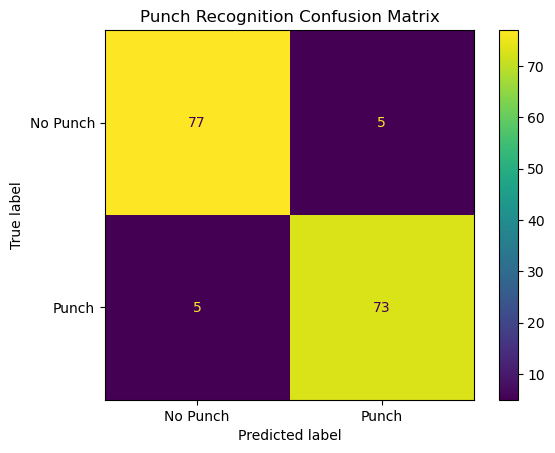

In [13]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=recognition_cm,
    display_labels=np.unique(y_recognition)
)
disp.plot()
plt.title("Punch Recognition Confusion Matrix")
plt.show()


In [14]:

# =========================
# 8. STAGE 2: PUNCH TYPE CLASSIFICATION
# =========================

punch_mask = y_all != "No Punch"

classification_results, classification_report_text, classification_cm, y_test_cls, y_pred_cls = active_learning_run(
    X_all.loc[punch_mask].reset_index(drop=True),
    y_all[punch_mask],
    task_name="Punch Classification"
)

classification_results


,task,train_ratio,labeled_train_samples,test_samples,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Punch Classification,0.05,16,78,0.884615,0.894527,0.884615,0.882999
1,Punch Classification,0.10,31,78,0.948718,0.952575,0.948718,0.949099
2,Punch Classification,0.15,46,78,0.948718,0.951235,0.948718,0.949082


In [15]:
print(classification_report_text)


              precision    recall  f1-score   support

        Hook       0.87      0.95      0.91        21
         Jab       1.00      1.00      1.00        24
    Uppercut       0.97      0.91      0.94        33

    accuracy                           0.95        78
   macro avg       0.95      0.95      0.95        78
weighted avg       0.95      0.95      0.95        78



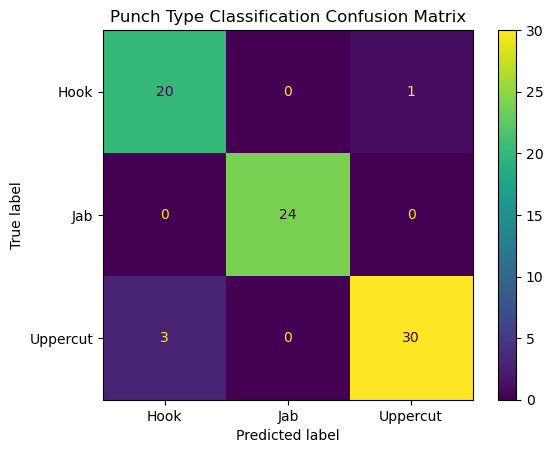

In [16]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=classification_cm,
    display_labels=np.unique(y_all[punch_mask])
)
disp.plot()
plt.title("Punch Type Classification Confusion Matrix")
plt.show()


In [17]:

# =========================
# 9. SAVE RESULTS
# =========================

summary = pd.concat([recognition_results, classification_results], ignore_index=True)
summary.to_csv("summary_metrics.csv", index=False)
meta_all.to_csv("window_metadata.csv", index=False)

print("Saved:")
print("- summary_metrics.csv")
print("- window_metadata.csv")
summary


Saved:
- summary_metrics.csv
- window_metadata.csv


,task,train_ratio,labeled_train_samples,test_samples,accuracy,precision_weighted,recall_weighted,f1_weighted
0,Punch Recognition,0.05,32,160,0.956250,0.958103,0.956250,0.956241
1,Punch Recognition,0.10,64,160,0.950000,0.950313,0.950000,0.950008
2,Punch Recognition,0.15,96,160,0.937500,0.937500,0.937500,0.937500
3,Punch Classification,0.05,16,78,0.884615,0.894527,0.884615,0.882999
4,Punch Classification,0.10,31,78,0.948718,0.952575,0.948718,0.949099
5,Punch Classification,0.15,46,78,0.948718,0.951235,0.948718,0.949082


In [18]:
# Final recognition model (Dataset1 дээр бүх data-гаар fit хийнэ)
y_recognition = np.where(y_all == "No Punch", "No Punch", "Punch")

recognition_model = QueryByCommittee()
recognition_model.fit(X_all, y_recognition)

print("Recognition model is ready.")

Recognition model is ready.


In [19]:
# Final classification model (зөвхөн punch data дээр fit хийнэ)
punch_mask = y_all != "No Punch"

classification_model = QueryByCommittee()
classification_model.fit(
    X_all.loc[punch_mask].reset_index(drop=True),
    y_all[punch_mask]
)

print("Classification model is ready.")

Classification model is ready.


In [20]:
df2 = pd.read_csv("JackR.csv")
print(df2.shape)
print(df2.columns.tolist())
df2.head()

(95341, 26)
['SensorId', ' TimeStamp (s)', ' FrameNumber', ' AccX (g)', ' AccY (g)', ' AccZ (g)', ' GyroX (deg/s)', ' GyroY (deg/s)', ' GyroZ (deg/s)', ' MagX (uT)', ' MagY (uT)', ' MagZ (uT)', ' EulerX (deg)', ' EulerY (deg)', ' EulerZ (deg)', ' QuatW', ' QuatX', ' QuatY', ' QuatZ', ' LinAccX (g)', ' LinAccY (g)', ' LinAccZ (g)', ' Pressure (kPa)', ' Altitude (m)', ' Temperature (degC)', ' HeaveMotion (m)']


,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,2,0.000,0,0.264141,0.938063,-0.283654,20.581001,39.395702,-15.480357,12.582200,...,-0.246960,-0.557747,0.783692,-0.007800,-0.005899,0.027996,0.0,0.0,0.0,0.0
1,2,0.005,1,0.266842,0.936793,-0.281237,20.403618,39.255737,-15.340582,12.669881,...,-0.247820,-0.557008,0.783691,-0.010866,-0.004748,0.024783,0.0,0.0,0.0,0.0
2,2,0.010,2,0.270033,0.937008,-0.279791,20.120398,38.766624,-15.099100,12.669881,...,-0.248670,-0.556277,0.783686,-0.014413,-0.005083,0.022549,0.0,0.0,0.0,0.0
3,2,0.015,3,0.272474,0.935518,-0.279825,19.908545,38.207848,-14.859019,12.012275,...,-0.249507,-0.555551,0.783680,-0.017195,-0.003715,0.021801,0.0,0.0,0.0,0.0
4,2,0.020,4,0.273451,0.933780,-0.278869,19.624969,37.753750,-14.722138,12.012275,...,-0.250333,-0.554834,0.783671,-0.018507,-0.002099,0.020074,0.0,0.0,0.0,0.0


In [21]:
FEATURE_COLS_2 = [
    "AccX (g)",
    "AccY (g)",
    "AccZ (g)",
    "GyroX (deg/s)",
    "GyroY (deg/s)",
    "GyroZ (deg/s)"
]

TIME_COL_2 = "TimeStamp (s)"
STEP_SIZE = 20

In [22]:
def create_sliding_windows_dataset2(df, window_size=180, step=20):
    rows = []
    meta = []

    for start in range(0, len(df) - window_size + 1, step):
        end = start + window_size
        window = df.iloc[start:end]

        feats = extract_window_features(window, FEATURE_COLS_2)
        rows.append(feats)

        center = start + window_size // 2

        meta.append({
            "start_index": start,
            "end_index": end - 1,
            "center_index": center,
            "center_time_s": df.iloc[center][TIME_COL_2]
        })

    return pd.DataFrame(rows), pd.DataFrame(meta)

In [23]:
df2.columns = df2.columns.str.strip()
print(df2.columns.tolist())

['SensorId', 'TimeStamp (s)', 'FrameNumber', 'AccX (g)', 'AccY (g)', 'AccZ (g)', 'GyroX (deg/s)', 'GyroY (deg/s)', 'GyroZ (deg/s)', 'MagX (uT)', 'MagY (uT)', 'MagZ (uT)', 'EulerX (deg)', 'EulerY (deg)', 'EulerZ (deg)', 'QuatW', 'QuatX', 'QuatY', 'QuatZ', 'LinAccX (g)', 'LinAccY (g)', 'LinAccZ (g)', 'Pressure (kPa)', 'Altitude (m)', 'Temperature (degC)', 'HeaveMotion (m)']


In [24]:
X_new, meta_new = create_sliding_windows_dataset2(df2, WINDOW_SIZE, STEP_SIZE)

print(X_new.shape)
meta_new.head()

(4759, 72)


,start_index,end_index,center_index,center_time_s
0,0,179,90,0.470
1,20,199,110,0.570
2,40,219,130,0.670
3,60,239,150,0.770
4,80,259,170,0.875


In [25]:
y_pred_rec_new = recognition_model.predict(X_new)

meta_new["recognition_pred"] = y_pred_rec_new
meta_new.head(10)

,start_index,end_index,center_index,center_time_s,recognition_pred
0,0,179,90,0.470,No Punch
1,20,199,110,0.570,No Punch
2,40,219,130,0.670,No Punch
3,60,239,150,0.770,No Punch
4,80,259,170,0.875,No Punch
5,100,279,190,0.975,No Punch
6,120,299,210,1.075,No Punch
7,140,319,230,1.185,No Punch
8,160,339,250,1.285,No Punch
9,180,359,270,1.385,No Punch


In [26]:
meta_new["recognition_pred"].value_counts()

recognition_pred
No Punch    3091
Punch       1668
Name: count, dtype: int64

In [27]:
punch_idx = np.where(meta_new["recognition_pred"] == "Punch")[0]

X_new_punch = X_new.iloc[punch_idx].reset_index(drop=True)

y_pred_type_new = classification_model.predict(X_new_punch)

meta_new["type_pred"] = None
meta_new.loc[punch_idx, "type_pred"] = y_pred_type_new

meta_new.head(20)

,start_index,end_index,center_index,center_time_s,recognition_pred,type_pred
0,0,179,90,0.470,No Punch,None
1,20,199,110,0.570,No Punch,None
2,40,219,130,0.670,No Punch,None
3,60,239,150,0.770,No Punch,None
4,80,259,170,0.875,No Punch,None
5,100,279,190,0.975,No Punch,None
6,120,299,210,1.075,No Punch,None
7,140,319,230,1.185,No Punch,None
8,160,339,250,1.285,No Punch,None
9,180,359,270,1.385,No Punch,None


In [28]:
predicted_punches = meta_new[meta_new["recognition_pred"] == "Punch"].copy()

print(predicted_punches.shape)
predicted_punches.head(20)

(1668, 6)


,start_index,end_index,center_index,center_time_s,recognition_pred,type_pred
229,4580,4759,4670,24.740,Punch,Jab
1273,25460,25639,25550,140.690,Punch,Hook
1274,25480,25659,25570,140.790,Punch,Hook
1275,25500,25679,25590,140.890,Punch,Hook
1276,25520,25699,25610,141.030,Punch,Hook
1277,25540,25719,25630,141.130,Punch,Hook
1302,26040,26219,26130,143.860,Punch,Jab
1303,26060,26239,26150,144.000,Punch,Jab
1304,26080,26259,26170,144.100,Punch,Jab
1305,26100,26279,26190,144.255,Punch,Jab


In [29]:
predicted_punches.to_csv("dataset2_predictions.csv", index=False)
print("Saved: dataset2_predictions.csv")

Saved: dataset2_predictions.csv


In [30]:
predicted_punches = predicted_punches.sort_values("center_time_s")

predicted_punches["new_event"] = (
    predicted_punches["center_time_s"].diff() > 1.0
)

predicted_punches["event_id"] = predicted_punches["new_event"].cumsum()

final_events = predicted_punches.groupby("event_id").agg({
    "center_time_s": "mean",
    "type_pred": lambda x: x.mode()[0]
}).reset_index(drop=True)

final_events

,center_time_s,type_pred
0,24.740000,Jab
1,140.906000,Hook
2,174.392565,Jab
3,208.031667,Jab
4,214.323636,Uppercut
5,223.370385,Hook
6,226.870909,Jab
7,230.610667,Jab
8,238.434231,Jab
9,241.030714,Jab


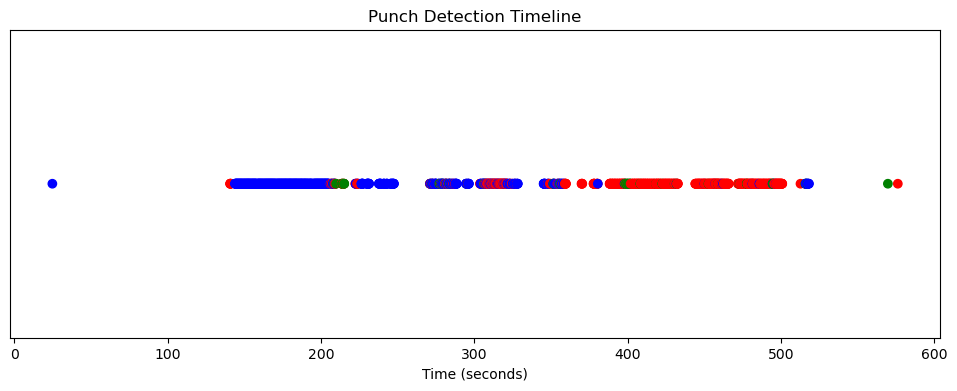

In [31]:
plt.figure(figsize=(12,4))

plt.scatter(
    predicted_punches["center_time_s"],
    [1]*len(predicted_punches),
    c=predicted_punches["type_pred"].map({
        "Jab":"blue",
        "Hook":"red",
        "Uppercut":"green"
    })
)

plt.yticks([])
plt.xlabel("Time (seconds)")
plt.title("Punch Detection Timeline")
plt.show()

In [32]:
final_events["type_pred"].value_counts()

type_pred
Jab         16
Hook        12
Uppercut     2
Name: count, dtype: int64

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ACC_COLS = ["AccX (g)", "AccY (g)", "AccZ (g)"]
GYRO_COLS = ["GyroX (deg/s)", "GyroY (deg/s)", "GyroZ (deg/s)"]
TIME_COL = "TimeStamp (s)"

# Copy raw dataset
df_signal = df2.copy()

# Resultant linear acceleration
df_signal["acc_resultant"] = np.sqrt(
    df_signal["AccX (g)"]**2 +
    df_signal["AccY (g)"]**2 +
    df_signal["AccZ (g)"]**2
)

# Resultant rotational velocity
df_signal["gyro_resultant"] = np.sqrt(
    df_signal["GyroX (deg/s)"]**2 +
    df_signal["GyroY (deg/s)"]**2 +
    df_signal["GyroZ (deg/s)"]**2
)

# Approx jerk = rate of change of resultant acceleration
dt = df_signal[TIME_COL].diff().median()
df_signal["jerk"] = df_signal["acc_resultant"].diff() / dt

print("Estimated dt:", dt)
df_signal.head()

Estimated dt: 0.0049999999999954525


,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m),acc_resultant,gyro_resultant,jerk
0,2,0.000,0,0.264141,0.938063,-0.283654,20.581001,39.395702,-15.480357,12.582200,...,-0.007800,-0.005899,0.027996,0.0,0.0,0.0,0.0,1.014984,47.066341,NaN
1,2,0.005,1,0.266842,0.936793,-0.281237,20.403618,39.255737,-15.340582,12.669881,...,-0.010866,-0.004748,0.024783,0.0,0.0,0.0,0.0,1.013845,46.825783,-0.227833
2,2,0.010,2,0.270033,0.937008,-0.279791,20.120398,38.766624,-15.099100,12.669881,...,-0.014413,-0.005083,0.022549,0.0,0.0,0.0,0.0,1.014487,46.213249,0.128587
3,2,0.015,3,0.272474,0.935518,-0.279825,19.908545,38.207848,-14.859019,12.012275,...,-0.017195,-0.003715,0.021801,0.0,0.0,0.0,0.0,1.013774,45.573898,-0.142665
4,2,0.020,4,0.273451,0.933780,-0.278869,19.624969,37.753750,-14.722138,12.012275,...,-0.018507,-0.002099,0.020074,0.0,0.0,0.0,0.0,1.012170,45.024731,-0.320822


In [34]:
def extract_event_metrics(
    df_signal,
    final_events,
    time_col="TimeStamp (s)",
    baseline_threshold=1.0,
    search_radius_sec=1.0
):
    results = []

    times = df_signal[time_col].to_numpy()
    acc = df_signal["acc_resultant"].to_numpy()
    jerk = df_signal["jerk"].fillna(0).to_numpy()
    gyro = df_signal["gyro_resultant"].to_numpy()

    for i, row in final_events.iterrows():
        event_time = row["center_time_s"]
        punch_type = row["type_pred"]

        # Local window around detected event
        mask = (times >= event_time - search_radius_sec) & (times <= event_time + search_radius_sec)
        local = df_signal.loc[mask].copy()

        if len(local) < 5:
            continue

        local = local.reset_index(drop=False)
        local_acc = local["acc_resultant"].to_numpy()
        local_times = local[time_col].to_numpy()
        local_jerk = local["jerk"].fillna(0).to_numpy()
        local_gyro = local["gyro_resultant"].to_numpy()

        # Peak = local max acceleration
        peak_local_idx = np.argmax(local_acc)
        peak_time = local_times[peak_local_idx]
        peak_acc = local_acc[peak_local_idx]

        # Start = nearest point before peak where acc drops below threshold
        start_idx = 0
        for j in range(peak_local_idx, -1, -1):
            if local_acc[j] <= baseline_threshold:
                start_idx = j
                break

        # End = nearest point after peak where acc drops below threshold
        end_idx = len(local_acc) - 1
        for j in range(peak_local_idx, len(local_acc)):
            if local_acc[j] <= baseline_threshold:
                end_idx = j
                break

        start_time = local_times[start_idx]
        end_time = local_times[end_idx]

        forward_time = peak_time - start_time
        retraction_time = end_time - peak_time

        # Peak jerk inside event
        jerk_segment = local_jerk[start_idx:end_idx+1]
        peak_jerk = np.nanmax(np.abs(jerk_segment)) if len(jerk_segment) > 0 else np.nan

        # Retraction acceleration trend
        retract_segment = local_acc[peak_local_idx:end_idx+1]
        avg_retraction_acc = np.nanmean(retract_segment) if len(retract_segment) > 0 else np.nan

        # Peak rotational velocity during extension phase
        extension_gyro = local_gyro[start_idx:peak_local_idx+1]
        peak_rotation = np.nanmax(extension_gyro) if len(extension_gyro) > 0 else np.nan

        results.append({
            "event_id": i + 1,
            "type_pred": punch_type,
            "event_time": event_time,
            "start_time": start_time,
            "peak_time": peak_time,
            "end_time": end_time,
            "forward_time": forward_time,
            "retraction_time": retraction_time,
            "peak_acc": peak_acc,
            "peak_jerk": peak_jerk,
            "avg_retraction_acc": avg_retraction_acc,
            "peak_rotation": peak_rotation
        })

    return pd.DataFrame(results)

event_metrics = extract_event_metrics(
    df_signal=df_signal,
    final_events=final_events,
    time_col=TIME_COL,
    baseline_threshold=1.0,
    search_radius_sec=1.0
)

event_metrics.head()

,event_id,type_pred,event_time,start_time,peak_time,end_time,forward_time,retraction_time,peak_acc,peak_jerk,avg_retraction_acc,peak_rotation
0,1,Jab,24.740000,24.510,24.540,24.780,0.030,0.240,7.446604,379.873098,2.321070,418.978695
1,2,Hook,140.906000,140.395,140.600,140.755,0.205,0.155,3.090414,59.721157,1.503190,1409.589191
2,3,Jab,174.392565,174.150,174.205,174.370,0.055,0.165,6.694939,239.483485,2.967117,1053.398290
3,4,Jab,208.031667,207.035,207.070,207.255,0.035,0.185,8.925824,788.016777,2.747461,2151.355959
4,5,Uppercut,214.323636,213.325,215.210,215.320,1.885,0.110,6.533629,204.288325,5.567288,838.951997


In [35]:
if len(event_metrics) > 1:
    session_duration = event_metrics["event_time"].max() - event_metrics["event_time"].min()
    punches_per_minute = (len(event_metrics) / session_duration) * 60 if session_duration > 0 else np.nan
else:
    session_duration = np.nan
    punches_per_minute = np.nan

print("Total punches:", len(event_metrics))
print("Session duration (s):", session_duration)
print("Punch cadence (PPM):", punches_per_minute)

Total punches: 30
Session duration (s): 551.535
Punch cadence (PPM): 3.2636188093230714


In [36]:
event_metrics

,event_id,type_pred,event_time,start_time,peak_time,end_time,forward_time,retraction_time,peak_acc,peak_jerk,avg_retraction_acc,peak_rotation
0,1,Jab,24.740000,24.510,24.540,24.780,0.030,0.240,7.446604,379.873098,2.321070,418.978695
1,2,Hook,140.906000,140.395,140.600,140.755,0.205,0.155,3.090414,59.721157,1.503190,1409.589191
2,3,Jab,174.392565,174.150,174.205,174.370,0.055,0.165,6.694939,239.483485,2.967117,1053.398290
3,4,Jab,208.031667,207.035,207.070,207.255,0.035,0.185,8.925824,788.016777,2.747461,2151.355959
4,5,Uppercut,214.323636,213.325,215.210,215.320,1.885,0.110,6.533629,204.288325,5.567288,838.951997
5,6,Hook,223.370385,223.465,223.690,223.845,0.225,0.155,10.439194,483.767243,3.942093,2392.996285
6,7,Jab,226.870909,226.655,227.060,227.260,0.405,0.200,9.796986,500.473783,3.010719,2005.923132
7,8,Jab,230.610667,230.185,231.020,231.255,0.835,0.235,13.536149,769.774886,3.345298,2241.074051
8,9,Jab,238.434231,238.495,238.770,239.005,0.275,0.235,18.464818,1203.418124,4.114880,2450.019095
9,10,Jab,241.030714,240.665,240.960,241.075,0.295,0.115,17.634687,1190.423917,5.689897,2421.695942


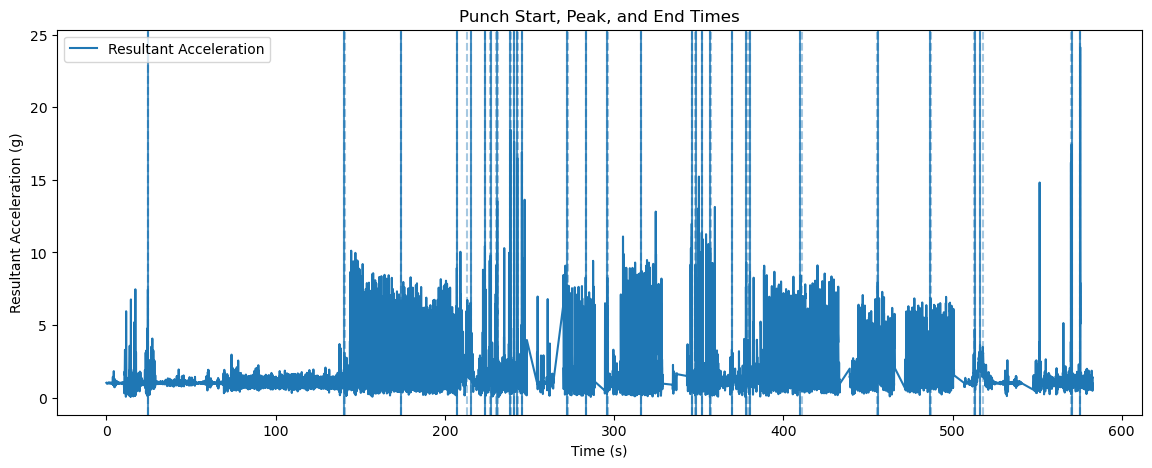

In [37]:
plt.figure(figsize=(14,5))
plt.plot(df_signal[TIME_COL], df_signal["acc_resultant"], label="Resultant Acceleration")

for _, row in event_metrics.iterrows():
    plt.axvline(row["start_time"], linestyle="--", alpha=0.4)
    plt.axvline(row["peak_time"], linestyle="-", alpha=0.8)
    plt.axvline(row["end_time"], linestyle="--", alpha=0.4)

plt.title("Punch Start, Peak, and End Times")
plt.xlabel("Time (s)")
plt.ylabel("Resultant Acceleration (g)")
plt.legend()
plt.show()

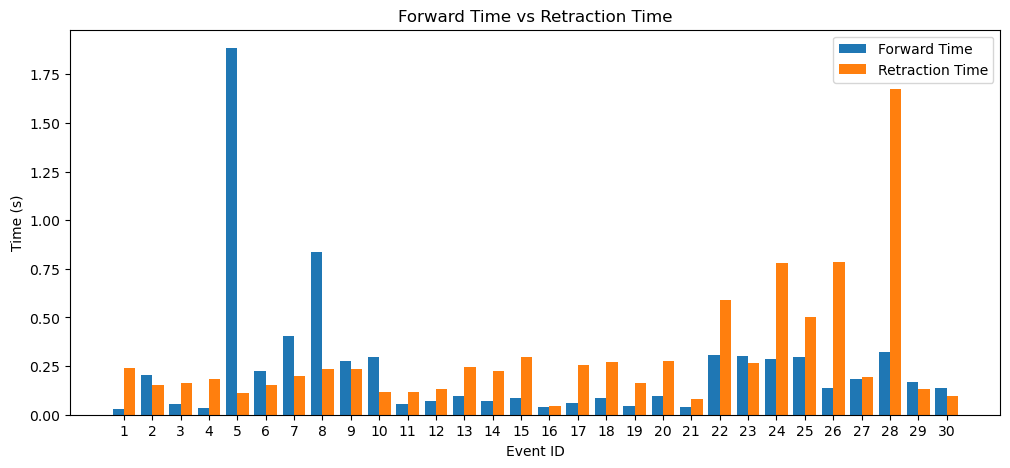

In [38]:
plt.figure(figsize=(12,5))
x = np.arange(len(event_metrics))

plt.bar(x - 0.2, event_metrics["forward_time"], width=0.4, label="Forward Time")
plt.bar(x + 0.2, event_metrics["retraction_time"], width=0.4, label="Retraction Time")

plt.xticks(x, event_metrics["event_id"])
plt.xlabel("Event ID")
plt.ylabel("Time (s)")
plt.title("Forward Time vs Retraction Time")
plt.legend()
plt.show()

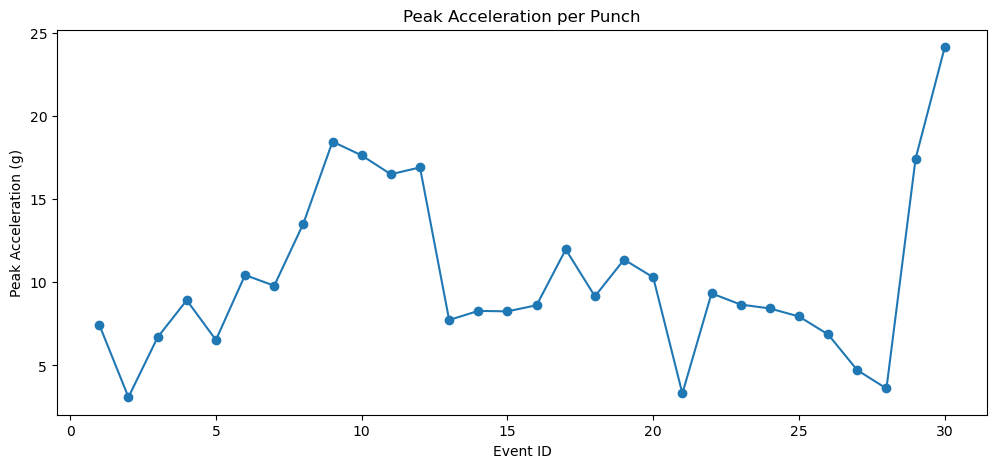

In [39]:
plt.figure(figsize=(12,5))
plt.plot(event_metrics["event_id"], event_metrics["peak_acc"], marker="o")
plt.xlabel("Event ID")
plt.ylabel("Peak Acceleration (g)")
plt.title("Peak Acceleration per Punch")
plt.show()

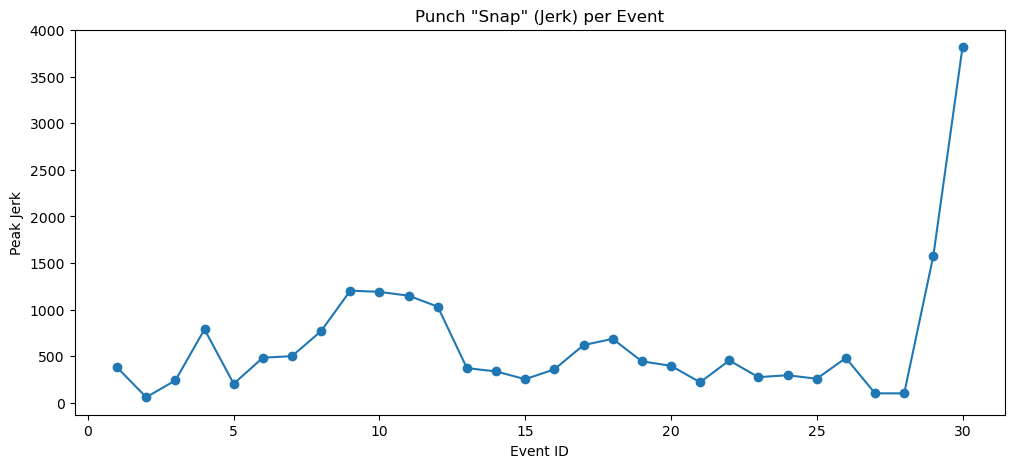

In [40]:
plt.figure(figsize=(12,5))
plt.plot(event_metrics["event_id"], event_metrics["peak_jerk"], marker="o")
plt.xlabel("Event ID")
plt.ylabel("Peak Jerk")
plt.title('Punch "Snap" (Jerk) per Event')
plt.show()

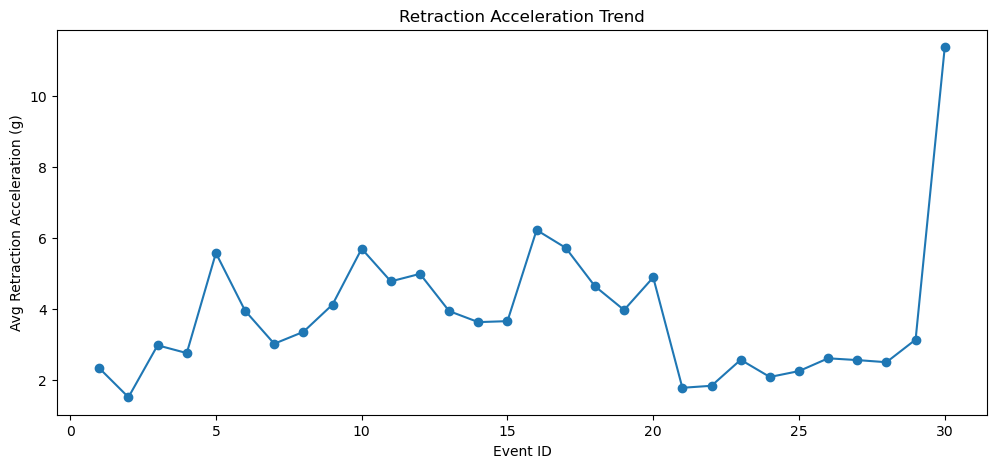

In [41]:
plt.figure(figsize=(12,5))
plt.plot(event_metrics["event_id"], event_metrics["avg_retraction_acc"], marker="o")
plt.xlabel("Event ID")
plt.ylabel("Avg Retraction Acceleration (g)")
plt.title("Retraction Acceleration Trend")
plt.show()

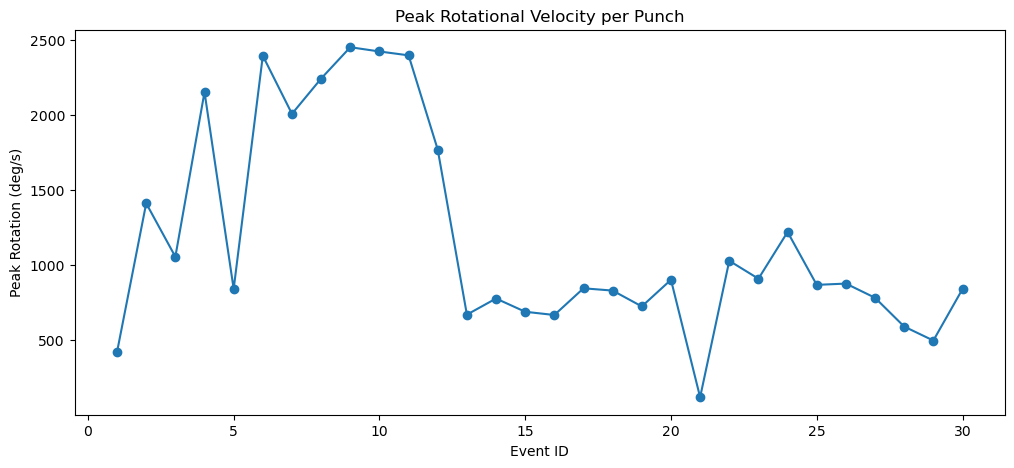

In [42]:
plt.figure(figsize=(12,5))
plt.plot(event_metrics["event_id"], event_metrics["peak_rotation"], marker="o")
plt.xlabel("Event ID")
plt.ylabel("Peak Rotation (deg/s)")
plt.title("Peak Rotational Velocity per Punch")
plt.show()

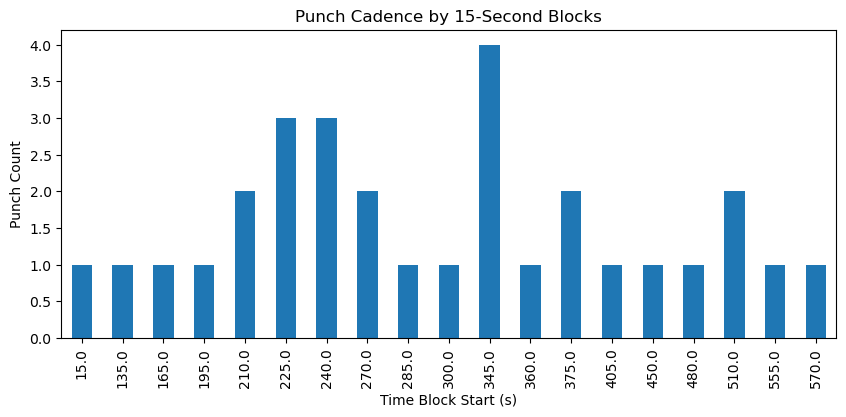

In [43]:
event_metrics["time_block"] = (event_metrics["event_time"] // 15) * 15
cadence_blocks = event_metrics.groupby("time_block").size()

plt.figure(figsize=(10,4))
cadence_blocks.plot(kind="bar")
plt.title("Punch Cadence by 15-Second Blocks")
plt.xlabel("Time Block Start (s)")
plt.ylabel("Punch Count")
plt.show()

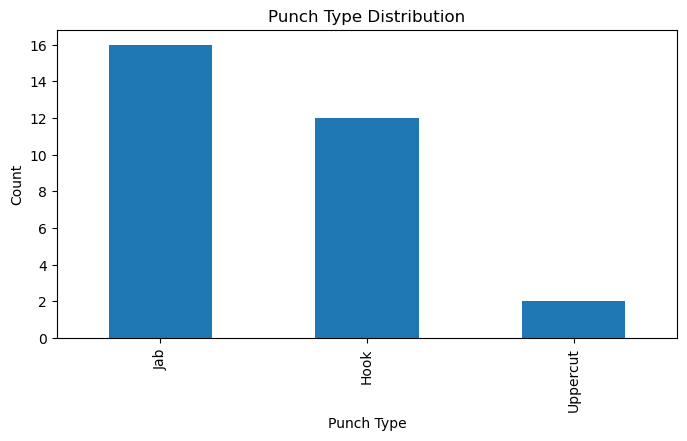

In [44]:
plt.figure(figsize=(8,4))
event_metrics["type_pred"].value_counts().plot(kind="bar")
plt.title("Punch Type Distribution")
plt.xlabel("Punch Type")
plt.ylabel("Count")
plt.show()

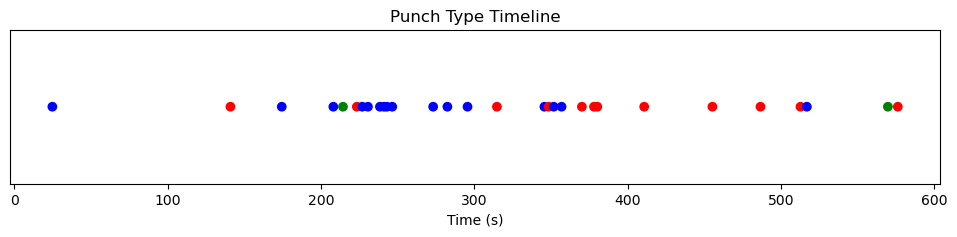

In [45]:
color_map = {"Jab": "blue", "Hook": "red", "Uppercut": "green"}

plt.figure(figsize=(12,2))
plt.scatter(
    event_metrics["event_time"],
    [1] * len(event_metrics),
    c=event_metrics["type_pred"].map(color_map)
)
plt.yticks([])
plt.xlabel("Time (s)")
plt.title("Punch Type Timeline")
plt.show()

In [46]:
summary_by_type = event_metrics.groupby("type_pred").agg({
    "forward_time": "mean",
    "retraction_time": "mean",
    "peak_acc": "mean",
    "peak_jerk": "mean",
    "avg_retraction_acc": "mean",
    "peak_rotation": "mean"
}).round(3)

summary_by_type

,forward_time,retraction_time,peak_acc,peak_jerk,avg_retraction_acc,peak_rotation
type_pred,,,,,,
Hook,0.186,0.326,8.727,624.135,3.607,993.590
Jab,0.177,0.297,11.091,611.022,3.887,1380.529
Uppercut,1.027,0.120,11.989,891.028,4.347,666.893


In [47]:
event_metrics.to_csv("boxing_event_insights.csv", index=False)
summary_by_type.to_csv("boxing_type_summary.csv")
print("Saved: boxing_event_insights.csv")
print("Saved: boxing_type_summary.csv")

Saved: boxing_event_insights.csv
Saved: boxing_type_summary.csv
